First 5 Rows
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0      

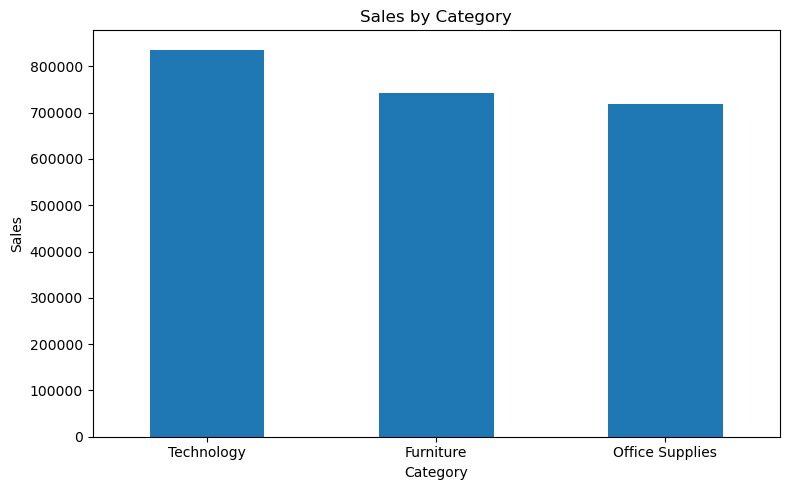

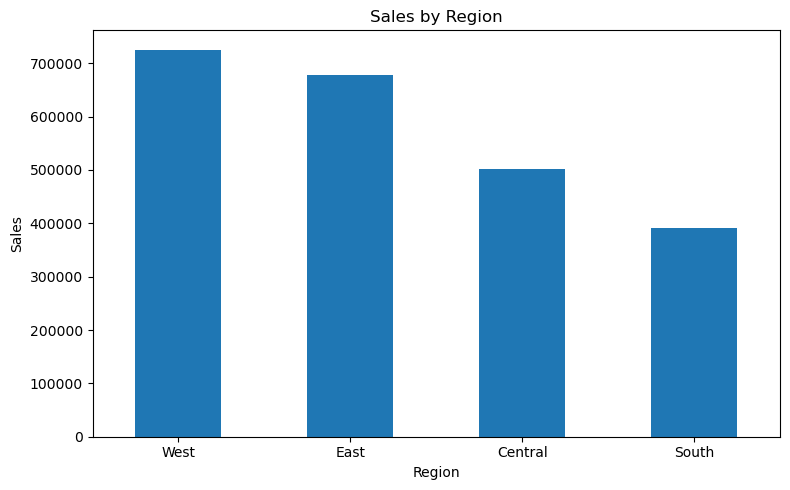

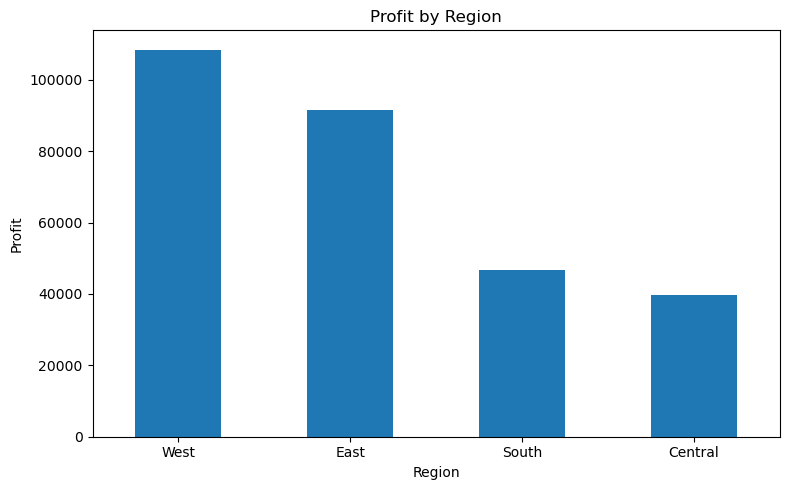

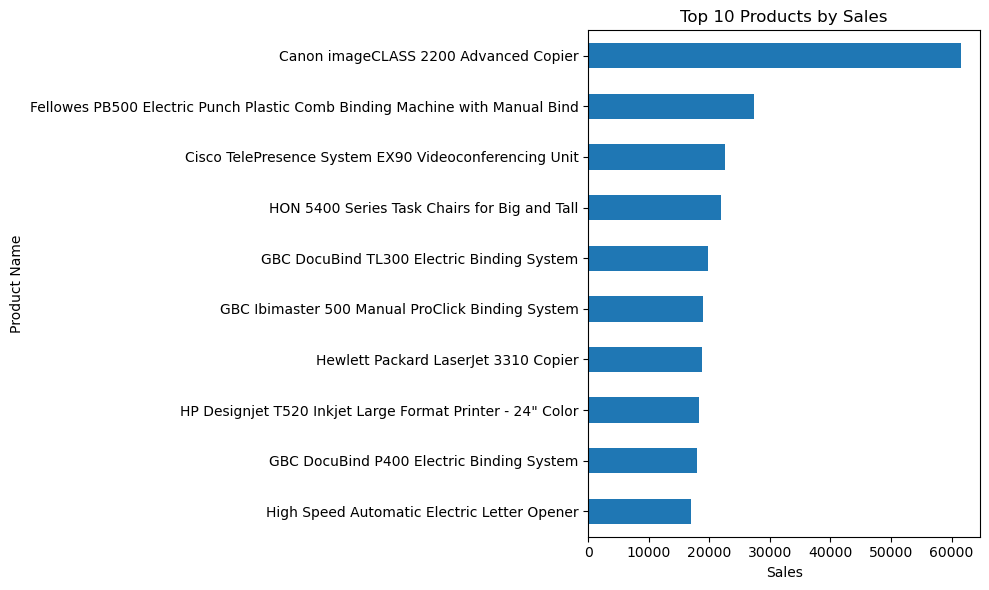

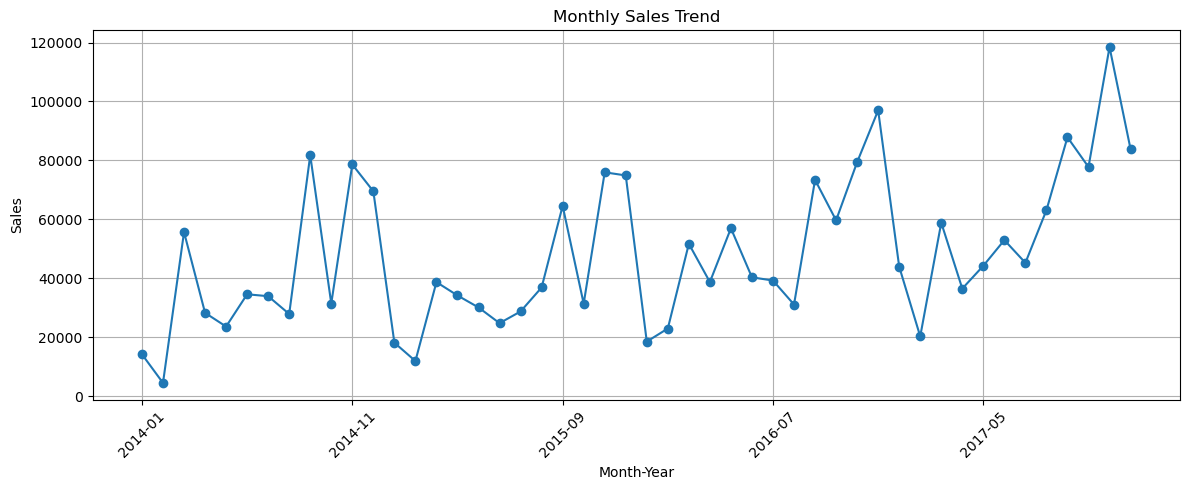

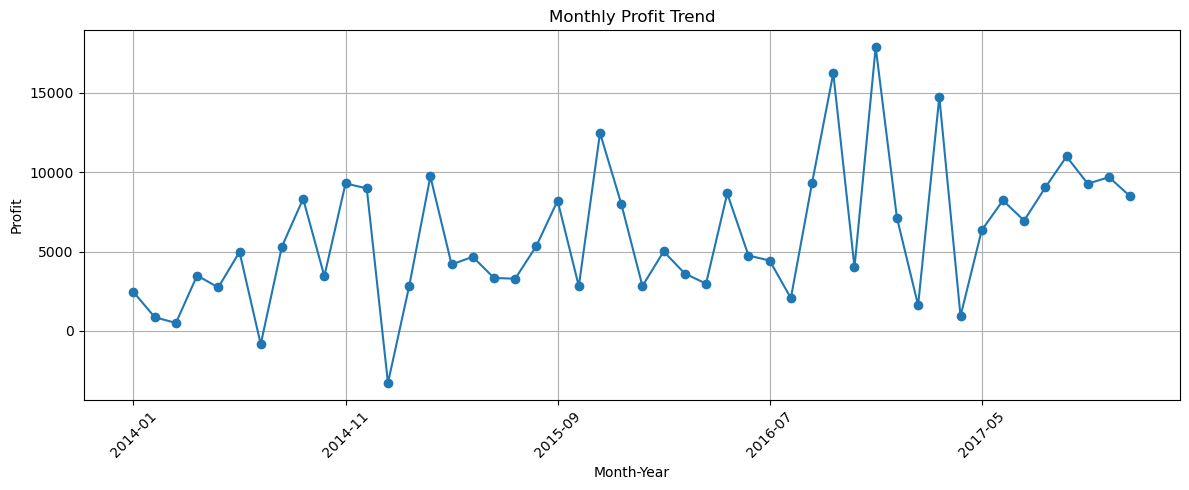

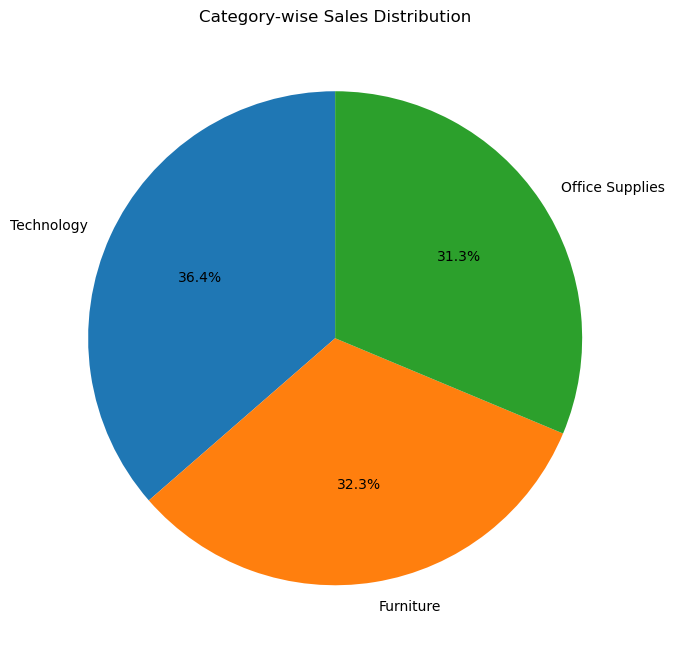

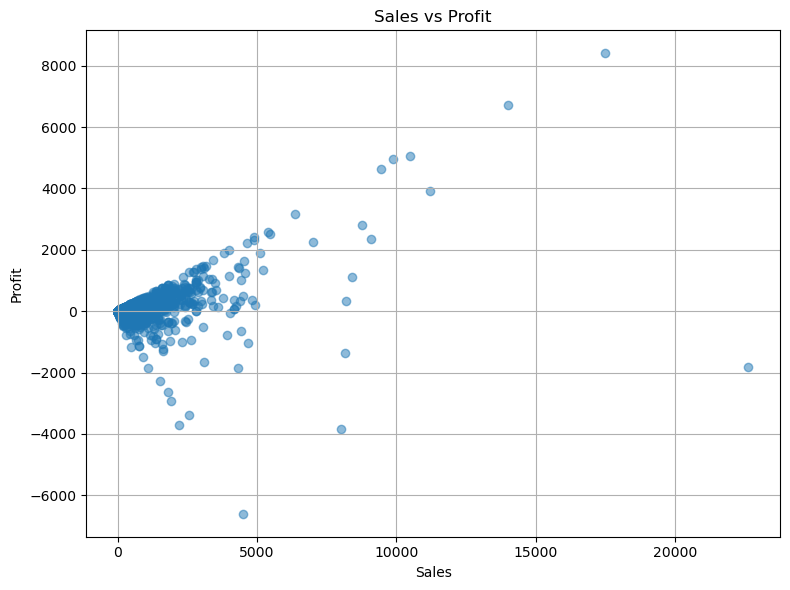


========== BUSINESS INSIGHTS ==========

1. Total Sales: $2,297,200.86
2. Total Profit: $286,397.02

Top Category:
Category
Technology    836154.033
Name: Sales, dtype: float64

Best Region:
Region
West    725457.8245
Name: Sales, dtype: float64

Most Profitable Region:
Region
West    108418.4489
Name: Profit, dtype: float64

Top 5 Products:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64

Project Completed Successfully!


In [1]:
# ==========================================
# SALES DATA ANALYSIS DASHBOARD PROJECT
# ==========================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. Load Dataset
# ==========================================

df = pd.read_csv("Sample - Superstore.csv", encoding="Windows-1252")

print("="*50)
print("First 5 Rows")
print("="*50)
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nDataset Shape:", df.shape)

print("\nColumn Names")
print(df.columns.tolist())

# ==========================================
# 2. Data Cleaning
# ==========================================

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Check missing values
print("\nMissing Values")
print(df.isnull().sum())

# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# ==========================================
# 3. Feature Engineering
# ==========================================

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()
df["Month-Year"] = df["Order Date"].dt.to_period("M").astype(str)

# ==========================================
# 4. Export Cleaned Dataset
# ==========================================

df.to_csv("Cleaned_Superstore.csv", index=False)

print("\nCleaned dataset saved successfully!")

# ==========================================
# 5. Key Performance Indicators (KPIs)
# ==========================================

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
average_sales = df["Sales"].mean()

print("\n========== KPI ==========")
print(f"Total Sales   : ${total_sales:,.2f}")
print(f"Total Profit  : ${total_profit:,.2f}")
print(f"Total Orders  : {total_orders}")
print(f"Average Sales : ${average_sales:,.2f}")

# ==========================================
# 6. Sales by Category
# ==========================================

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# 7. Sales by Region
# ==========================================

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# 8. Profit by Region
# ==========================================

region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_profit.plot(kind="bar")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# 9. Top 10 Products
# ==========================================

top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

# ==========================================
# 10. Monthly Sales Trend
# ==========================================

monthly_sales = (
    df.groupby("Month-Year")["Sales"]
      .sum()
)

plt.figure(figsize=(12,5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month-Year")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 11. Monthly Profit Trend
# ==========================================

monthly_profit = (
    df.groupby("Month-Year")["Profit"]
      .sum()
)

plt.figure(figsize=(12,5))
monthly_profit.plot(kind="line", marker="o")
plt.title("Monthly Profit Trend")
plt.xlabel("Month-Year")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 12. Category Distribution
# ==========================================

plt.figure(figsize=(7,7))
category_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.ylabel("")
plt.title("Category-wise Sales Distribution")
plt.tight_layout()
plt.show()

# ==========================================
# 13. Sales vs Profit
# ==========================================

plt.figure(figsize=(8,6))
plt.scatter(df["Sales"], df["Profit"], alpha=0.5)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 14. Business Insights
# ==========================================

print("\n========== BUSINESS INSIGHTS ==========\n")

print(f"1. Total Sales: ${total_sales:,.2f}")
print(f"2. Total Profit: ${total_profit:,.2f}")

print("\nTop Category:")
print(category_sales.head(1))

print("\nBest Region:")
print(region_sales.head(1))

print("\nMost Profitable Region:")
print(region_profit.head(1))

print("\nTop 5 Products:")
print(top_products.head())

print("\nProject Completed Successfully!")